In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
import time

In [2]:
X_blobs, y_blobs = make_blobs(
    n_samples=500,
    n_features=4,
    centers=4,
    cluster_std=1.2,
    random_state=42
)

print(f"Data shape: {X_blobs.shape}")
print(f"True labels: {np.unique(y_blobs)}")

Data shape: (500, 4)
True labels: [0 1 2 3]


In [3]:
kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

kmeans.fit(X_blobs)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

print(f"Inertia (WCSS): {kmeans.inertia_:.2f}")
print(f"Iterations to converge: {kmeans.n_iter_}")
print(f"Centroids:\n{centroids.round(2)}")

Inertia (WCSS): 2805.98
Iterations to converge: 2
Centroids:
[[-2.5   9.05  4.61  1.95]
 [ 2.15  4.24 -9.43  9.49]
 [ 6.64 -5.56 -6.43 -6.35]
 [-6.88 -6.88 -8.76  7.47]]


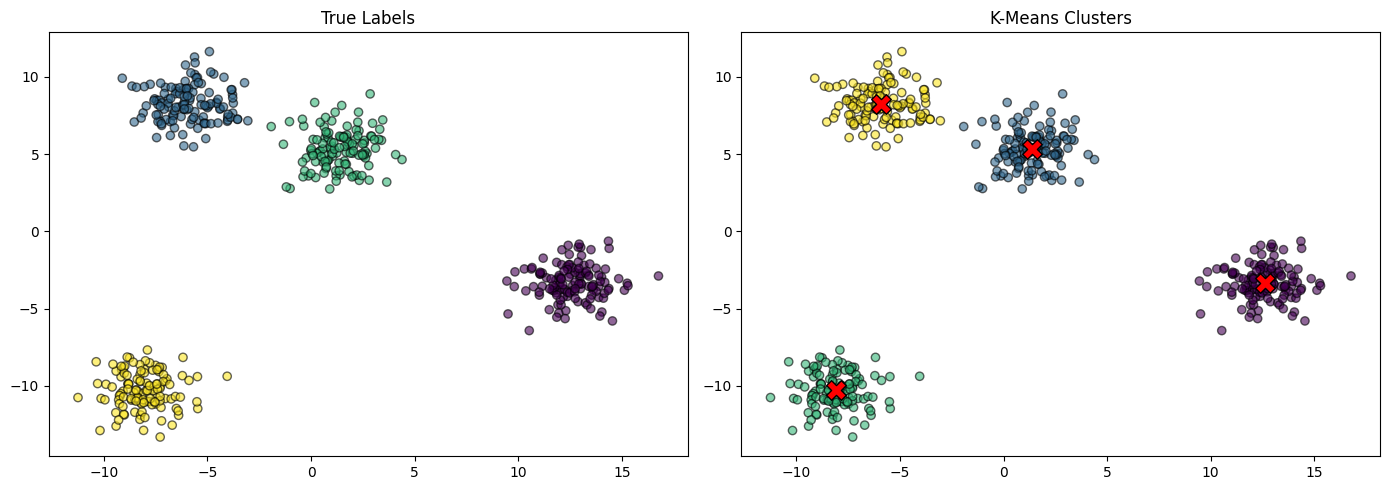

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_blobs)
centroids_pca = pca.transform(centroids)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_blobs, cmap='viridis', alpha=0.6, edgecolors='k')
axes[0].set_title('True Labels')
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.6, edgecolors='k')
axes[1].scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200, edgecolors='black')
axes[1].set_title('K-Means Clusters')
plt.tight_layout()
plt.show()

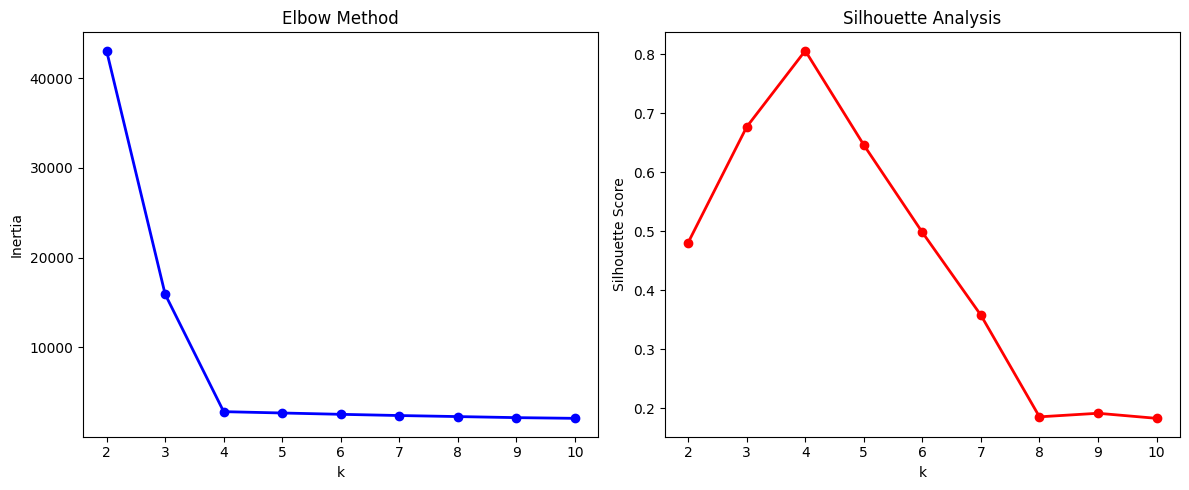

In [5]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_blobs)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_blobs, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[1].plot(K_range, silhouettes, 'ro-', linewidth=2)
axes[1].set_title('Silhouette Analysis')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

In [6]:
sil = silhouette_score(X_blobs, labels)
ch = calinski_harabasz_score(X_blobs, labels)
db = davies_bouldin_score(X_blobs, labels)

print(f"Silhouette: {sil:.4f}  (higher is better, range -1 to 1)")
print(f"Calinski-Harabasz: {ch:.2f}  (higher is better)")
print(f"Davies-Bouldin: {db:.4f}  (lower is better)")

Silhouette: 0.8056  (higher is better, range -1 to 1)
Calinski-Harabasz: 4116.32  (higher is better)
Davies-Bouldin: 0.2765  (lower is better)


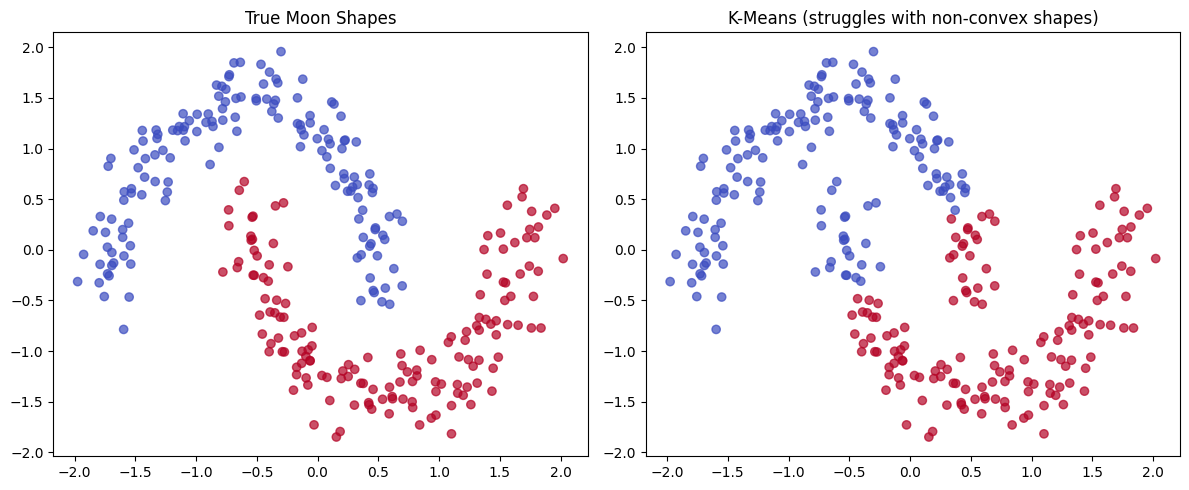

In [7]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.1, random_state=42)
X_moons_scaled = StandardScaler().fit_transform(X_moons)

kmeans_moons = KMeans(n_clusters=2, random_state=42).fit(X_moons_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], c=y_moons, cmap='coolwarm', alpha=0.7)
axes[0].set_title('True Moon Shapes')
axes[1].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], c=kmeans_moons.labels_, cmap='coolwarm', alpha=0.7)
axes[1].set_title('K-Means (struggles with non-convex shapes)')
plt.tight_layout()
plt.show()

In [8]:
new_samples = np.random.randn(5, 4) * 2
new_labels = kmeans.predict(new_samples)
new_distances = kmeans.transform(new_samples)

for i, (label, dists) in enumerate(zip(new_labels, new_distances)):
    print(f"Sample {i+1}: Cluster {label}, Distances: {dists.round(2)}")

Sample 1: Cluster 0, Distances: [10.29 13.15 12.05 17.43]
Sample 2: Cluster 0, Distances: [10.9  17.49 14.88 16.99]
Sample 3: Cluster 0, Distances: [11.62 18.63 15.36 16.83]
Sample 4: Cluster 2, Distances: [12.35 11.45 10.8  15.17]
Sample 5: Cluster 1, Distances: [12.82 11.53 11.97 12.25]


In [9]:
X_large, _ = make_blobs(n_samples=100000, centers=4, random_state=42)

start = time.time()
km_std = KMeans(n_clusters=4, random_state=42, n_init=3).fit(X_large)
t_std = time.time() - start

start = time.time()
km_mini = MiniBatchKMeans(n_clusters=4, random_state=42, batch_size=1000, n_init=3).fit(X_large)
t_mini = time.time() - start

print(f"Standard: {t_std:.3f}s, Inertia: {km_std.inertia_:.2f}")
print(f"MiniBatch: {t_mini:.3f}s, Inertia: {km_mini.inertia_:.2f}")
print(f"Speedup: {t_std/t_mini:.1f}x")

Standard: 0.218s, Inertia: 199880.24
MiniBatch: 0.030s, Inertia: 199901.67
Speedup: 7.3x
